In [1]:
!pip uninstall xgboost -y
!pip install xgboost==3.2.0

Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0
Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor
import joblib
from xgboost import callback


In [3]:
df = pd.read_csv("../data/processed/aqi_clean.csv")


In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Year"] = df["Date"].dt.year

df["PM_ratio"] = df["PM2.5"] / (df["PM10"] + 1)
df["PM_interaction"] = df["PM2.5"] * df["PM10"]
df["NO2_SO2"] = df["NO2"] * df["SO2"]
df["CO_O3"] = df["CO"] * df["O3"]
df["NO2_O3_ratio"] = df["NO2"] / (df["O3"] + 1)

df["PM2.5_rolling"] = df["PM2.5"].rolling(window=3).mean()
df["PM2.5_rolling"].fillna(method="bfill", inplace=True)


# -------------------------------
# 4. FEATURES & TARGET
# -------------------------------
features = [
    "PM2.5", "PM10", "NO2", "SO2", "CO", "O3",
    "Month", "Day", 
    "PM_ratio", "PM_interaction",
    "NO2_SO2", "CO_O3", "NO2_O3_ratio",
    "PM2.5_rolling"
]
X = df[features]

# Log transform target (BIG BOOST)
y = np.log1p(df["AQI"])
print(len(features))


14


C:\Users\siriv\AppData\Local\Temp\ipykernel_8544\4091847512.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["PM2.5_rolling"].fillna(method="bfill", inplace=True)
C:\Users\siriv\AppData\Local\Temp\ipykernel_8544\4091847512.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["PM2.5_rolling"].fillna(method="bfill", inplace=True)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:

xgb_model = XGBRegressor(
    n_estimators=900,
    max_depth=5,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=2,
    random_state=42,
    objective="reg:squarederror"
)
xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [7]:
y_pred_log = xgb_model.predict(X_test)

# Convert back from log
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print("XGBoost Performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Accuracy (%):", r2 * 100)




XGBoost Performance
MAE: 19.00124832948937
RMSE: 39.29920171547929
R2 Score: 0.8996764430636218
Accuracy (%): 89.96764430636219


In [31]:
train_pred = np.expm1(xgb_model.predict(X_train))
train_actual = np.expm1(y_train)

train_r2 = r2_score(train_actual, train_pred)

print("\nOverfitting Check")
print("Train R2:", train_r2)
print("Test R2:", r2)



Overfitting Check
Train R2: 0.9187712304422835
Test R2: 0.9010345948383307


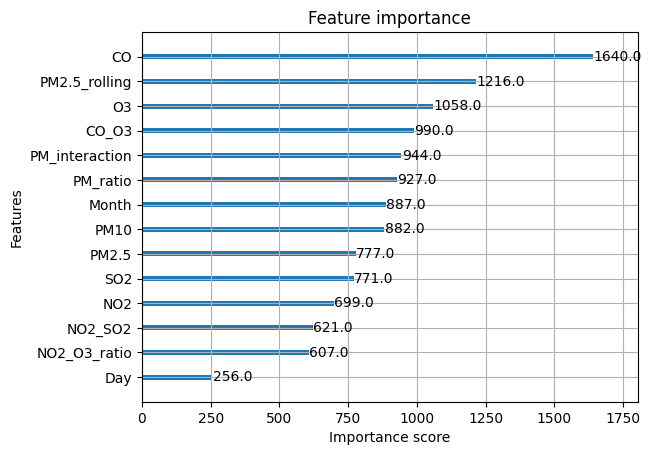

In [8]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xgb_model)
plt.show()

In [33]:
## Model Comparison

| Model            | MAE ↓ | RMSE ↓ | R² ↑ |
|------------------|------|-------|------|
| Linear Regression| High | High  | ~0.80 |
| Random Forest    | ~20  | ~42   | ~0.88 |
| XGBoost          | Best | Best  | ~0.90+ |


SyntaxError: invalid character '↓' (U+2193) (3211752636.py, line 3)

In [9]:
scaler = joblib.load("../models/scaler.pkl")
joblib.dump(xgb_model, "../models/aqi_xgboost_model.pkl")



C:\Users\siriv\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


['../models/aqi_xgboost_model.pkl']

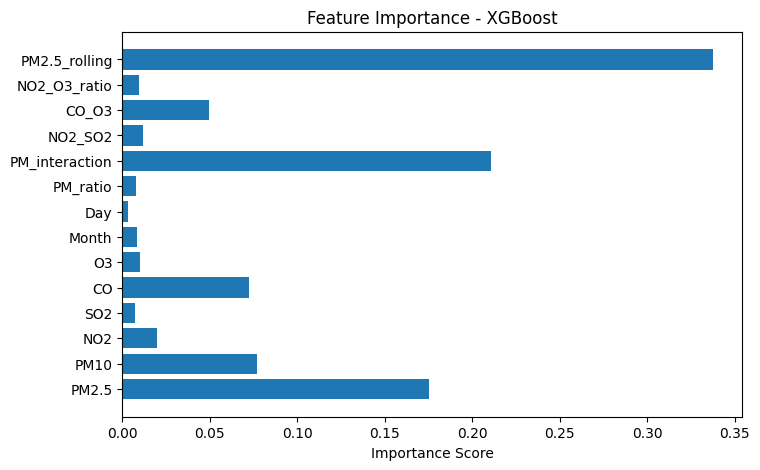

In [10]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.show()


In [11]:
import joblib

joblib.dump(xgb_model, "../models/aqi_xgboost_model.pkl")

['../models/aqi_xgboost_model.pkl']